 ### Understanding K-Means Clustering
 
 The Concept -  K-Means works in three repeating steps:
 * Initialization: Pick K random points as "starting centers" (centroids).
 * Assignment: Every data point joins the cluster of the centroid it is closest to.
 * Update: Move the centroids to the mathematical center (mean) of all their new members.
 * Repeat steps 2 and 3 until the centers stop moving!

 A Simple Example:
 Imagine you have a giant bucket of colorful candy—Skittles, M&Ms, and Reese's Pieces—all mixed together on a table. You want to organize them into groups, but you aren't allowed to look at the wrappers. You can only look at where they are sitting on the table.K-Means is like a robot that helps you sort them into $K$ piles (let’s say $K=3$ piles). Here is how the robot does it:
 * Step 1: Pick the "Captains". The robot closed its eyes and points to 3 random spots on the table. These spots are the "Captains" of the piles.
 * Step 2: Join a Team. Every piece of candy looks at the 3 Captains and asks: "Which one is closest to me?" * If you are closer to the Red Captain, you join the Red Team.If you are closer to the Blue Captain, you join the Blue Team.
 * Step 3: Move the Captains. Now, the Captains move! Each Captain walks to the exact middle of their new team. If the Red Team is mostly on the left side of the table, the Red Captain moves right into the center of that group.
 * Step 4: Repeat! Since the Captains moved, some candies might realize they are now closer to a different Captain. They switch teams, the Captains move again, and they keep doing this until nobody needs to switch anymore.
 * The Result: In the end, you have 3 perfect piles of candy! The robot didn't need to know what the candy was; it just used distance to find the best groups.

When does it stop?
The "regrouping" stops when the Captains reach the Balance Point. This is called Convergence.
The Captains are exactly in the middle of their teams.
No candy finds a closer Captain.
The robot declares: "The sorting is finished!"

### Setup and Data Generation
First, we need some "blobs" of data to play with.

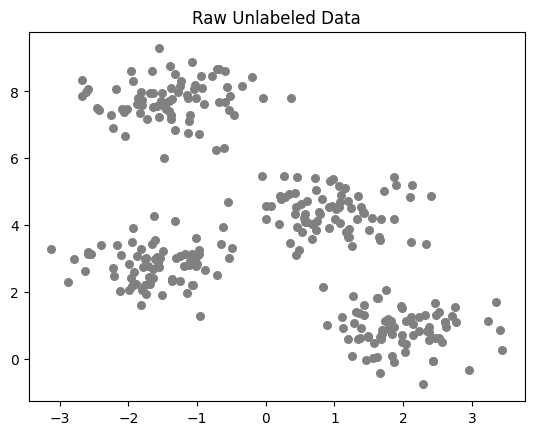

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create synthetic data: 300 points, 4 distinct clusters
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Visualize the raw data
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("Raw Unlabeled Data")
plt.show()

### Building the Model
Now we tell the computer to find those 4 clusters.

In [2]:
# 1. Initialize the model
# n_init='auto' tells it to try a few random starts to find the best one
kmeans = KMeans(n_clusters=4, n_init="auto")

# 2. Fit the model (This is where the 'Assignment' and 'Update' steps happen)
kmeans.fit(X)

# 3. Get the results
y_kmeans = kmeans.predict(X)
centers = kmeans.cluster_centers_

### Visualizing the Results
Let's see if the algorithm "saw" what we saw.

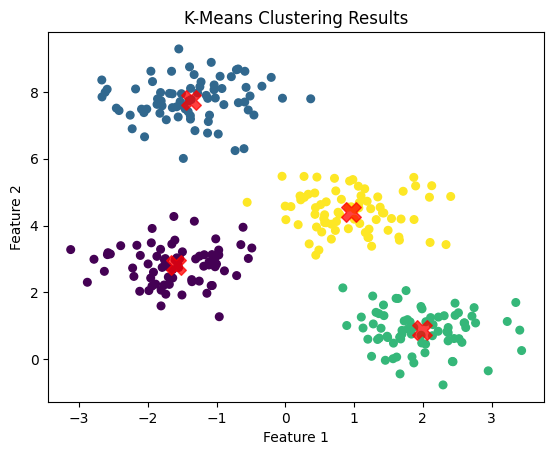

In [3]:
# Plot the data points colored by their cluster assignment
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap="viridis")

# Plot the centroids (the 'centers' the algorithm found)
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, alpha=0.75, marker="X")

plt.title("K-Means Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### How do we choose 'K'? (The Elbow Method)
In the real world, you don't always know there are 4 clusters. We use the Elbow Method to find the "sweet spot." We calculate Inertia (the sum of squared distances to the nearest cluster center).

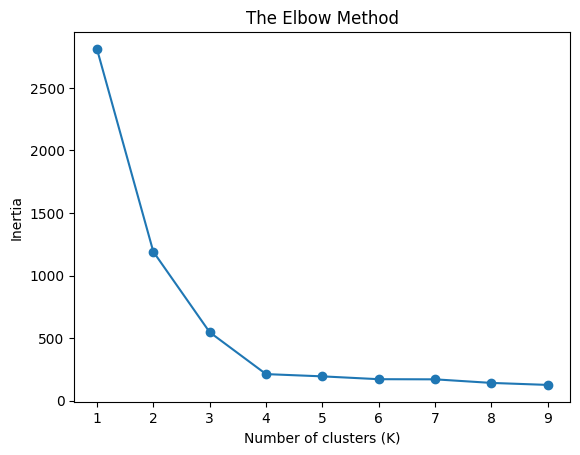

In [4]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init="auto")
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("The Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

Tip: Look for the "elbow" in the curve above. That’s the point where adding more clusters doesn't give you much more information—it's usually the "correct" number of clusters.